In [ ]:
#!pip install tensorflow opencv-python matplotlib seaborn scikit-learn tqdm --quiet

✅ Dataset loaded from: /content/sample_data/All_CS_rifat_data.csv
Shape: (20105, 43)

Class distribution:
cybersickness_class
None      9037
Low       5038
Medium    4500
High      1530
Name: count, dtype: int64
Train: (16084, 7, 7, 1), Test: (4021, 7, 7, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 7, 7, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,652 (108.02 KB)

 Trainable params: 27,652 (108.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4757 - loss: 1.1634 - val_accuracy: 0.6195 - val_loss: 0.9123
Epoch 2/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5921 - loss: 0.9387 - val_accuracy: 0.6652 - val_loss: 0.7797
Epoch 3/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6495 - loss: 0.8207 - val_accuracy: 0.7153 - val_loss: 0.6876
Epoch 4/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6983 - loss: 0.7330 - val_accuracy: 0.7650 - val_loss: 0.6341
Epoch 5/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7028 - loss: 0.7023 - val_accuracy: 0.7666 - val_loss: 0.5725
Epoch 6/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7193 - loss: 0.6680 - val_accuracy: 0.7777 - val_loss: 0.5515
Epoch 7/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7431 - loss: 0.6222 - val_accuracy: 0.7874 - val_loss: 0.5258
Epoch 8/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7510 - loss: 0.6117 - val_accuracy: 0

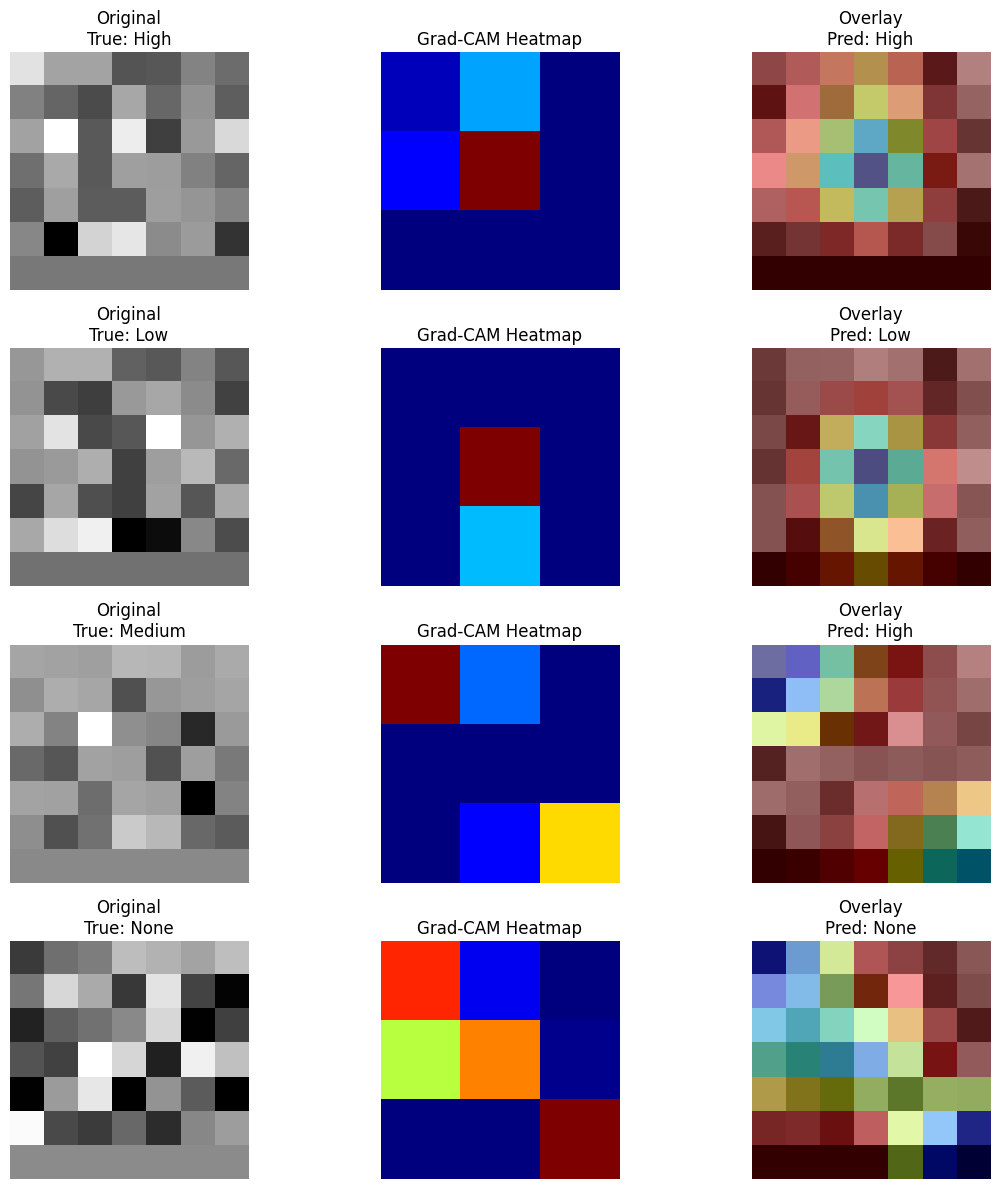

In [28]:


# --- Imports ---
import numpy as np, pandas as pd, cv2, matplotlib.pyplot as plt, tensorflow as tf, os
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ============================================
# STEP 1 – Load Dataset
# ============================================
data_path = "/content/sample_data/All_CS_rifat_data.csv"
data = pd.read_csv(data_path)
print(f"✅ Dataset loaded from: {data_path}")
print("Shape:", data.shape)

# Map fms → cybersickness classes
def map_fms_to_label(fms):
    if fms == 0: return "None"
    elif fms == 1: return "Low"
    elif fms in [2,3]: return "Medium"
    else: return "High"

data["cybersickness_class"] = data["fms"].apply(map_fms_to_label)
print("\nClass distribution:")
print(data["cybersickness_class"].value_counts())

# ============================================
# STEP 2 – Preprocess
# ============================================
X = data.drop(columns=["fms", "cybersickness_class"])
y = data["cybersickness_class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

num_features = X_scaled.shape[1]
img_size = int(np.ceil(np.sqrt(num_features)))   # e.g. 43 → 7×7
X_pad = np.zeros((X_scaled.shape[0], img_size**2))
X_pad[:, :num_features] = X_scaled
X_images = X_pad.reshape(-1, img_size, img_size, 1)

le = LabelEncoder()
y_enc = le.fit_transform(y)
y_cat = to_categorical(y_enc)

X_train, X_test, y_train, y_test = train_test_split(
    X_images, y_cat, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ============================================
# STEP 3 – Build & Train CNN
# ============================================
def build_cnn(img_size, n_classes):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(img_size,img_size,1)),
        MaxPooling2D((2,2)), Dropout(0.2),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)), Dropout(0.3),
        Flatten(), Dense(128, activation='relu'), Dropout(0.3),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_cnn(img_size, y_cat.shape[1])
model.summary()

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")

# ============================================
# 🩹 Fix Sequential -> Functional for Grad-CAM
# ============================================

# Ensure the model is "called" once to create its graph
print("📣 Forcing model build...")
dummy_input = tf.random.normal((1, img_size, img_size, 1))
_ = model(dummy_input, training=False)
print("✅ Model successfully called; graph built.")

# Now safely wrap into a functional graph
inputs = model.layers[0].input          # use first layer's input directly
outputs = model.layers[-1].output       # use last layer's output
model_func = tf.keras.Model(inputs=inputs, outputs=outputs)
print("🔒 Functional wrapper ready for Grad-CAM.")

# ============================================
# ✅ Fix 2: Use this stable Grad-CAM
# ============================================

def grad_cam_fixed(model_func, img_array, class_idx):
    """Final tested Grad-CAM: uses functional model, guaranteed to find Conv2D."""
    conv_layers = [l for l in model_func.layers if isinstance(l, tf.keras.layers.Conv2D)]
    if not conv_layers:
        raise RuntimeError("No Conv2D layer found — something overwrote model_func.")
    target = conv_layers[-1]

    grad_model = tf.keras.Model(inputs=model_func.input,
                                outputs=[target.output, model_func.output])

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array, training=False)
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    conv_out = conv_out[0]
    heat = tf.reduce_sum(tf.multiply(pooled, conv_out), axis=-1)
    heat = np.maximum(heat, 0)
    return heat / (np.max(heat) + 1e-8)

# ============================================
# ✅ Fix 3: Visualize Grad-CAMs (stable)
# ============================================
unique_classes = le.classes_
chosen_indices = []
for i, cname in enumerate(unique_classes):
    idxs = np.where(np.argmax(y_test, axis=1) == i)[0]
    if len(idxs) > 0:
        chosen_indices.append(np.random.choice(idxs))

plt.figure(figsize=(12, len(chosen_indices)*3))

for i, idx in enumerate(chosen_indices, 1):
    img = X_test[idx]
    true_label = np.argmax(y_test[idx])
    preds = model_func(img[np.newaxis, ...], training=False).numpy()
    pred_label = np.argmax(preds)

    true_name = le.inverse_transform([true_label])[0]
    pred_name = le.inverse_transform([pred_label])[0]

    # Grad-CAM from functional model
    heatmap = grad_cam_fixed(model_func, img[np.newaxis, ...], class_idx=pred_label)

    # Combine with original image
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    overlay = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    combo = cv2.addWeighted(
        cv2.cvtColor((img.squeeze()*255).astype(np.uint8), cv2.COLOR_GRAY2BGR),
        0.6, overlay, 0.4, 0
    )

    plt.subplot(len(chosen_indices), 3, (i-1)*3 + 1)
    plt.imshow(img.squeeze(), cmap='gray'); plt.title(f"Original\nTrue: {true_name}"); plt.axis('off')
    plt.subplot(len(chosen_indices), 3, (i-1)*3 + 2)
    plt.imshow(heatmap, cmap='jet'); plt.title("Grad-CAM Heatmap"); plt.axis('off')
    plt.subplot(len(chosen_indices), 3, (i-1)*3 + 3)
    plt.imshow(combo); plt.title(f"Overlay\nPred: {pred_name}"); plt.axis('off')

plt.tight_layout()
plt.show()
